# Ejercicio 1 - Práctica 6 - Parte 2

El dataset `student_data.csv` contiene información sobre el promedio de horas semanales de estudio que un conjunto de estudiantes dedicó para la preparación de un examen y la calificación final recibida luego de rendirlo.

1. Realice un gráfico que le permita visualizar la relación existente entre las calificaciones finales y las horas de estudio del grupo de estudiantes.

2. ¿Cómo describiría dicha relación a partir de lo observado?

3. ¿Qué métrica utilizaría para cuantificar el grado de asociación lineal entre ambas variables? Calcúlela e interprete el valor obtenido.

4. A partir de los datos, ajuste un modelo de regresión lineal para la calificación final del examen en función de las horas semanales de estudio. Represente gráficamente el modelo ajustado en el gráfico realizado en el ítem 1.

Escriba el modelo ajustado en forma desarrollada e interprete cada uno de los coeficientes que lo componen.

---

## Cargamos el df

In [2]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

In [5]:
# Cargamos el dataset
data = pd.read_csv('../../datasets/student_data.csv')
data.head()

,Unnamed: 0,hours_studied,exam_scores
0,1,9.3,63.1
1,2,23.9,90.4
2,3,12.9,63.2
3,4,26.6,87.8
4,5,28.3,92.9


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     245 non-null    int64  
 1   hours_studied  245 non-null    float64
 2   exam_scores    245 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 5.9 KB


## Ítem 1

Realice un gráfico que le permita visualizar la relación existente entre las calificaciones finales y las horas de estudio del grupo de estudiantes.

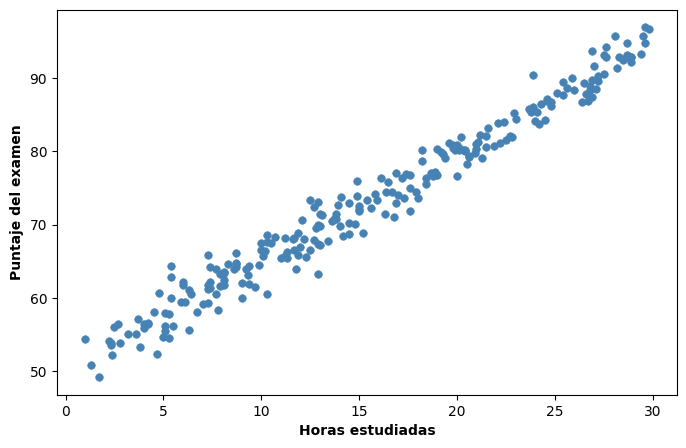

In [8]:
plt.figure(figsize = (8, 5))

sns.scatterplot(x = 'hours_studied', y = 'exam_scores', s = 30, color = 'steelblue',
                edgecolor = 'steelblue', data = data)

plt.xlabel('Horas estudiadas', fontweight = 'bold')
plt.ylabel('Puntaje del examen', fontweight = 'bold')

plt.show()

## Ítem 2

¿Cómo describiría dicha relación a partir de lo observado?

Observamos la relación entre las horas estudiadas y el puntaje del examen es aproximadamente lineal y positiva: a mayor horas de estudio, mayor puntaje. Además, el mismo sugiere una relación intensa, lo que justifica proponer un modelo de regresión lineal simple.

## Ítem 3

¿Qué métrica utilizaría para cuantificar el grado de asociación lineal entre ambas variables? Calcúlela e interprete el valor obtenido.

In [10]:
# La métrica adecuada es el coeficiente de correlación de Pearson:

correlation = data['hours_studied'].corr(data['exam_scores'])
print(f'El coeficiente de correlación de Pearson es: {correlation:.2f}')

# El valor cercano a 1 indica fuerte asociación lineal positiva.

El coeficiente de correlación de Pearson es: 0.99


## Ítem 4

A partir de los datos, ajuste un modelo de regresión lineal para la calificación final del examen en función de las horas semanales de estudio. Represente gráficamente el modelo ajustado en el gráfico realizado en el ítem 1.

Modelo propuesto:

$$Y = \beta_0 + \beta_1X + \varepsilon$$

donde:

- $Y$: calificación final;
- $X$: horas de estudio.

In [12]:
modelo = smf.ols(formula = 'exam_scores ~ hours_studied', data = data).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.11e-191
Time:                        11:50:49   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

El modelo resultante es

$$Y = 50.2541 + 1.4750 X.$$

In [13]:
# Agregamos la columna de predichos al DataFrame original

data['predichos'] = modelo.predict(data)
data.head()

,Unnamed: 0,hours_studied,exam_scores,predichos
0,1,9.3,63.1,63.971440
1,2,23.9,90.4,85.506152
2,3,12.9,63.2,69.281369
3,4,26.6,87.8,89.488599
4,5,28.3,92.9,91.996066


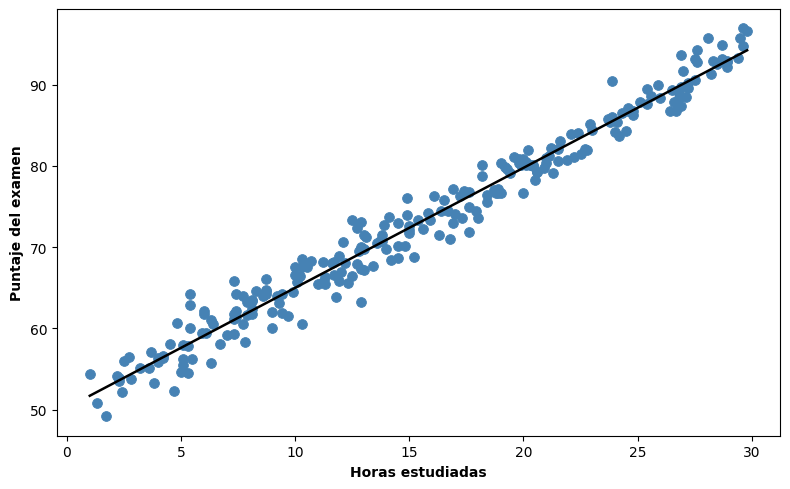

In [17]:
# Graficamos el modelo obtenido junto con los datos originales

fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'hours_studied', y = 'exam_scores', data = data,
                color = 'steelblue', edgecolor = 'steelblue', 
                s = 50, ax = ax)
sns.lineplot(x = 'hours_studied', y = 'predichos', data = data,
                color = 'black', linewidth = 1.8, ax = ax)

ax.set_xlabel('Horas estudiadas', fontweight = 'bold')
ax.set_ylabel('Puntaje del examen', fontweight = 'bold')

plt.tight_layout()
plt.show()